 Created: data/raw
 Created: data/processed
 Created: notebooks
 Created: scripts
 Created: dashboards
 Created: outputs/figures
 Created: outputs/reports
 Created: docs

Project structure created successfully!
copied file to: data/raw\retail_sales_data.csv
placed csv file in: data/raw

 Dataset loaded successfully!

INITIAL DATA INSPECTION

 Dataset shape: 10,000 rows x 19columns

First 5 Rows:
    Order_ID           Order_Date            Ship_Date Customer_ID  \
0  ORD000001  2022-01-01 00:00:00  2022-01-02 00:00:00    CUST1127   
1  ORD000002  2022-01-01 01:00:00  2022-01-02 01:00:00    CUST1460   
2  ORD000003  2022-01-01 02:00:00  2022-01-02 02:00:00    CUST0861   
3  ORD000004  2022-01-01 03:00:00  2022-01-02 03:00:00    CUST1295   
4  ORD000005  2022-01-01 04:00:00  2022-01-02 04:00:00    CUST1131   

   Customer_Name    Segment   Region Product_ID Product_Category  \
0  Customer_1275   Consumer  Central   PROD0215  Office Supplies   
1  Customer_1334  Corporate     East   PROD0

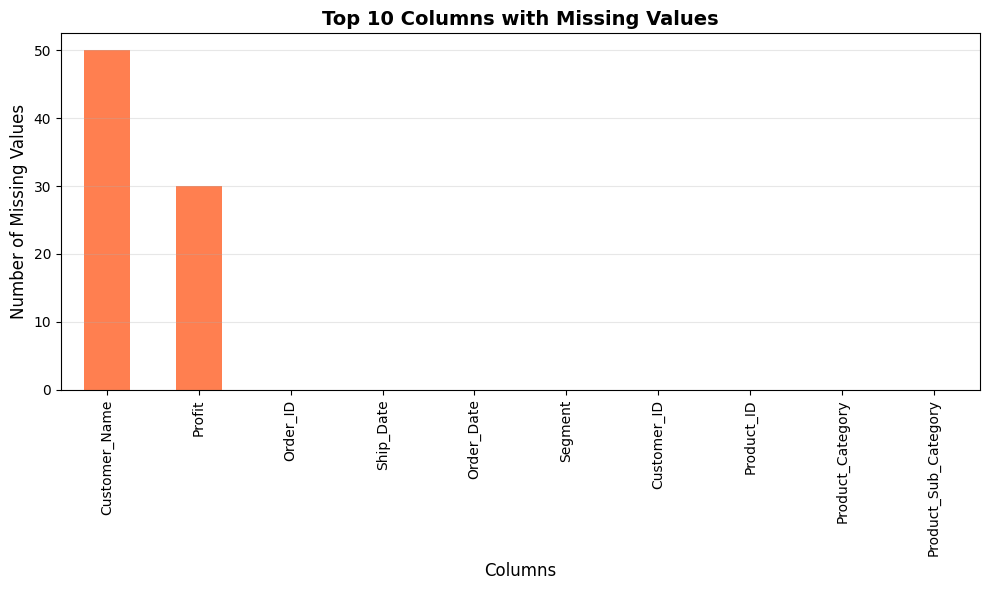

 Saved: 02_data_types_distribution.png


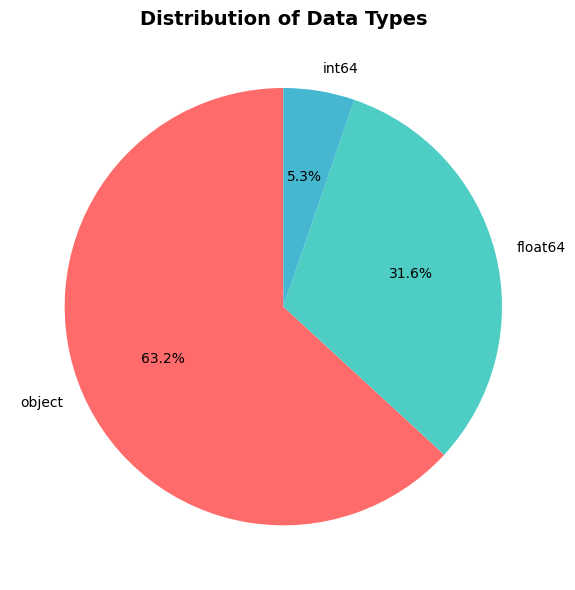

In [11]:
# Retail & Marketing Analytics Project
# Notebook 1: Notebook 1 – Data Loading & Cleaning

"""
Project: Retail & Marketing Analytics - Customer Segmentation & Sales Optimization
Part: 01 - Data Acquisition and Setup

Objective:
- Setup project environment
- Download dataset from Kaggle
- Initial data inspection
- Create project folder structure
"""


# ============================================================================
# 1. IMPORT LIBRARIES
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from pathlib import Path

# ============================================================================
# 2. CREATE PROJECT FOLDER STRUCTURE
# ============================================================================

# Define folder structure
folders = [
    'data/raw',
    'data/processed',
    'notebooks',
    'dashboards',
    'outputs/figures',
    'outputs/reports',
    'docs'
]

# Create folders
for folder in folders:
    Path(folder).mkdir(parents=True, exist_ok=True)
    print(f" Created: {folder}")

print("\nProject structure created successfully!")

# ============================================================================
# 3. LOAD DATASET
# ============================================================================

import shutil

# Source path 
source_file = "C:/Users/Home/Downloads/retail_sales_data.csv"

# Define new target directory and filename
target_dir = "data/raw"
os.makedirs(target_dir, exist_ok=True)
destination_file = os.path.join(target_dir, "retail_sales_data.csv")

#Copy file 
shutil.copy(source_file, destination_file)
print(f"copied file to: {destination_file}")

print("placed csv file in:", target_dir)

df_sales = pd.read_csv('data/raw/retail_sales_data.csv')
print("\n Dataset loaded successfully!")

# ============================================================================
# 5. INITIAL DATA INSPECTION
# ============================================================================

print("\n" + "="*80)
print("INITIAL DATA INSPECTION")
print("="*80)

# Dataset shape
print(f"\n Dataset shape: {df_sales.shape[0]:,} rows x {df_sales.shape[1]} columns")

# First few rows
print("\nFirst 5 Rows:")
print(df_sales.head())

# Last few rows
print("\nLast 5 Rows:")
print(df_sales.tail())

# Column information
print("\nColumn Information:")
print(df_sales.info())

# Data types
print("\nData Types:")
print(df_sales.dtypes)

# ============================================================================
# 6. BASIC STATISTICS
# ============================================================================

print("\n" + "="*80)
print("BASIC STATISTICAL SUMMARY")
print("="*80)

# Numerical columns summary
print("\n Numerical Columns Statistics:")
print(df_sales.describe())

# ============================================================================
# 7. DATA QUALITY CHECK
# ============================================================================

print("\n" + "="*80)
print("DATA QUALITY ASSESSMENT")
print("="*80)

# Missing values
print("\n Missing Values:")
missing_data = pd.DataFrame({
    'Column': df_sales.columns,
    'Missing_Count': df_sales.isnull().sum().values,
    'Missing_Percentage': (df_sales.isnull().sum().values / len(df_sales)* 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count']>0].sort_values('Missing_Count', ascending = False)
print(missing_data)

# Duplicate rows
duplicates = df_sales.duplicated().sum()
print(f"\n Duplicate Rows: {duplicates} ({(duplicates/len(df_sales)*100):.2f}%)")

# Unique values per column
print("\n Unique Values per Column:")
unique_counts= pd.DataFrame({
    'Column': df_sales.columns,
    'Unique_Count': [df_sales[col].nunique() for col in df_sales.columns],
    'Data_Type': df_sales.dtypes.values
})
print(unique_counts)

# ============================================================================
# 8. INITIAL VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("CREATING INITIAL VISUALIZATIONS")
print("="*80)

# Create visualization directory if not exists
os.makedirs('outputs/figures', exist_ok=True)

# 1. Missing values visualization
fig, ax = plt.subplots(figsize=(10,6))
missing_data_plot = df_sales.isnull().sum().sort_values(ascending=False)[:10]
missing_data_plot.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Top 10 Columns with Missing Values', fontsize=14, fontweight='bold')
ax.set_xlabel('Columns', fontsize=12)
ax.set_ylabel('Number of Missing Values', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/figures/01_missing_values.png', dpi=300, bbox_inches='tight')
print(" Saved:01_missing_values.png")
plt.show()

# 2. Data types distribution
fig,ax = plt.subplots(figsize=(8,6))
dtype_counts = df_sales.dtypes.value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
ax.pie(dtype_counts.values, labels=dtype_counts.index, autopct='%1.1f%%',
       startangle=90, colors=colors)
ax.set_title('Distribution of Data Types', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/02_data_types_distribution.png', dpi=300, bbox_inches='tight')
print(" Saved: 02_data_types_distribution.png")
plt.show()



DATA CLEANING AND PREPROCESSING

Initial Dataset Shape: (10000, 19)

STEP 1: HANDLING MISSING VALUES

 Treatment Strategy:
 Profit: Filled with median (20.33)
 Customer_Name: Filled with mode ('Customer_133')

 Missing values after treatment: 0

STEP 2: REMOVING DUPLICATES

 Duplicate rows found: 0
 Duplicates removed: 0
 New dataset shape: (10000, 19)

STEP 3: DATA TYPE CONVERSION
 converted Order_Date to datetime
 converted Ship_Date to datetime
 Converted Segment to category
 Converted Region to category
 Converted Product_Category to category
 Converted Product_Sub_Category to category
 Converted Order_Priority to category

STEP 4: OUTLIER DETECTION AND TREATMENT

 Outlier analysis:

Sales:
 - Outliers detected: 328 (3.28%)
 - Lower Bound: -71.87
 - Upper Bound: 275.33

Quantity:
 - Outliers detected: 0 (0.00%)
 - Lower Bound: -3.00
 - Upper Bound: 13.00

Profit:
 - Outliers detected: 87 (0.87%)
 - Lower Bound: -61.87
 - Upper Bound: 101.47

 Saved: 03_outliers_before_treatment.png

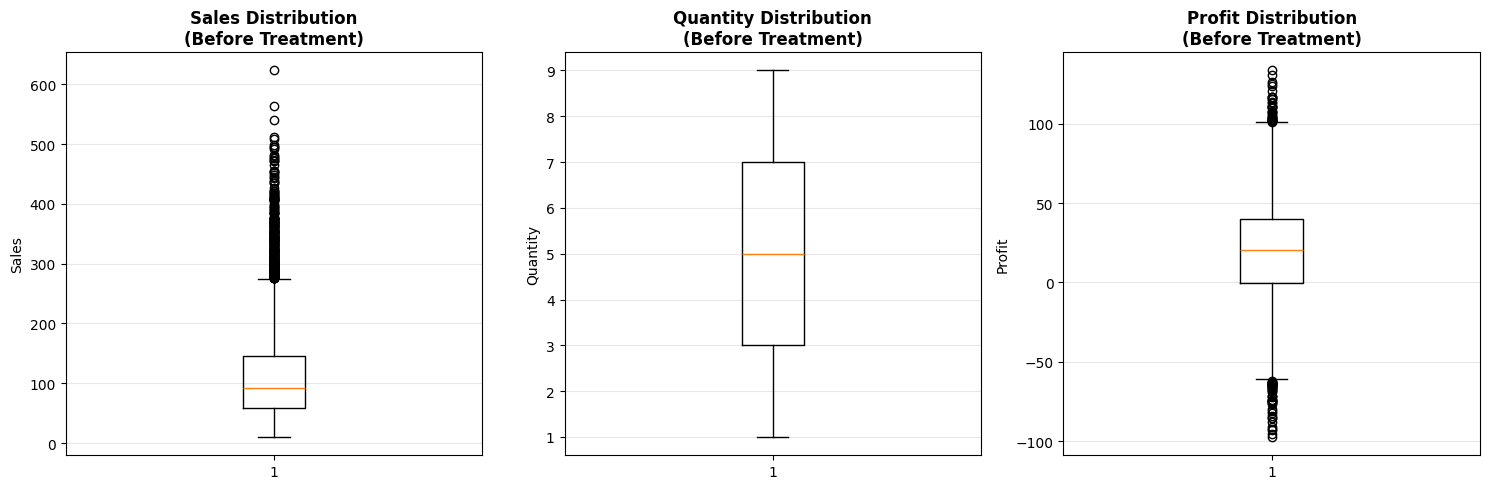


 Outlier Treatment (Capping):
 Sales: Outliers capped to [-71.87,275.33]
 Profit: Outliers capped to [-61.87,101.47]
 Saved: 04_outliers_after_treatment.png


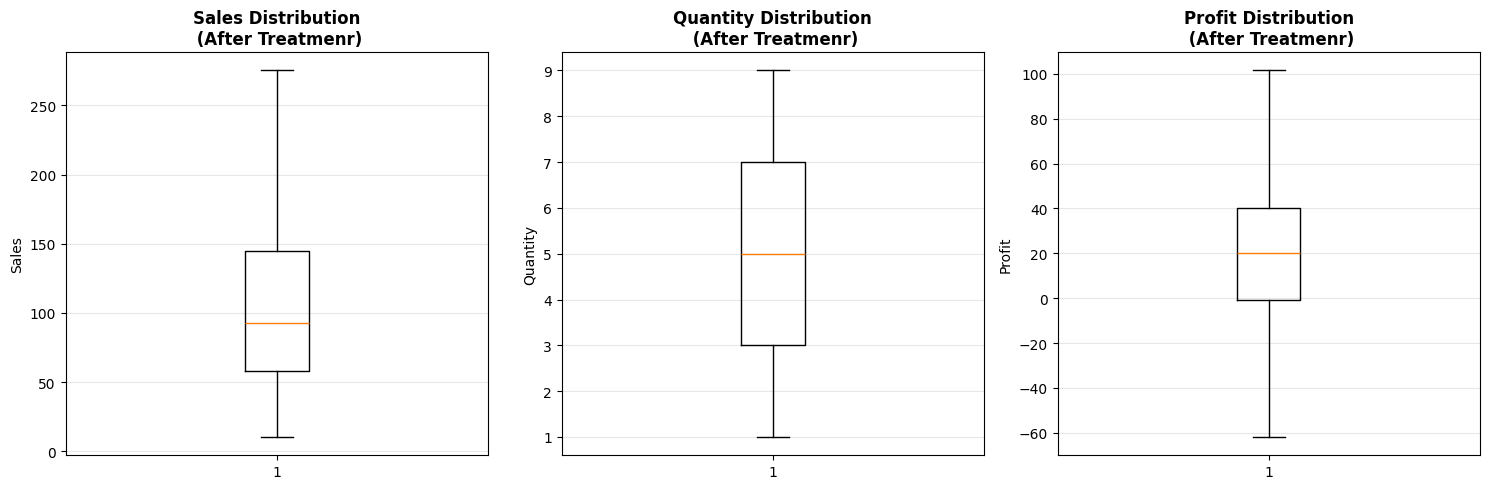


STEP 5: FEATURE ENGINEERING

 Creating Time-Based Features:

 Creating Revenue Metrics:

 Creating Delivery Metrics:

 Creating customer Flags:
Creating product metrics:

 Creating Seasonal Features:

 Feature Engineering Completed!

STEP 6: DATA VALIDATION
Negative Sales: 0
Zero or negative quantity: 0
Invalid discount values: 0
Ship date before order date: 0
Validation completed

CLEANED DATA SUMMARY

 Final Dataset Shape: (10000, 35)
 Records Removed: 0
Features Added: 16
Missing values: 0
Duplicate rows: 0

 Basic Statistics
Total Sales: 1078670.98
Average Order value: 107.87
Unique Customers: 1986
Unique Products: 499

STEP 7: SAVING CLEANED DATA
 Cleaned data saved: data/processed/cleaned_retail_sales.csv
 Data dictionary saved

NOTEBOOK 01 COMPLETED SUCCESSFULLY!

✅ Next Step: Open Notebook 02 - EDA (Exploratory Data Analysis)


In [22]:
"""
Project: Retail & Marketing Analytics - Customer Segmentation & Sales Optimization
Notebook: 02 - Data Cleaning and Preprocessing

Objective:
- Handle missing values
- Remove duplicates
- Convert data types
- Detect and treat outliers
- Feature engineering
- Save cleaned dataset
"""
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("DATA CLEANING AND PREPROCESSING")
print("="*80)
print(f"\nInitial Dataset Shape: {df_sales.shape}")

# Create a copy for cleaning
df_clean = df_sales.copy()

# ============================================================================
# 1. HANDLE MISSING VALUES
# ============================================================================

print("\n" + "="*80)
print("STEP 1: HANDLING MISSING VALUES")
print("="*80)

# Strategy for handling missing values
print("\n Treatment Strategy:")

# Separate columns by type
numerical_cols = df_clean.select_dtypes(include=['float64','int64']).columns.tolist()
categorical_cols =  df_clean.select_dtypes(include=['object']).columns.tolist()

# Handle numerical missing values- fill with median
for col in numerical_cols:
    if df_clean[col].isnull().sum()>0:
        median_value = df_clean[col].median()
        df_clean[col].fillna(median_value,inplace = True)
        print(f" {col}: Filled with median ({median_value:.2f})")

# Handle categorical missing values - Fill with mode or 'Unknown'
for col in categorical_cols:
    if df_clean[col].isnull().sum()>0:
        if df_clean[col].mode().empty:
            df_clean[col].fillna('Unknown', inplace=True)
            print(f" {col}: Filled with 'Unknown'")
        else:
            mode_value =df_clean[col].mode()[0]
            df_clean[col].fillna(mode_value,inplace=True)
            print(f" {col}: Filled with mode ('{mode_value}')")

# Verify no missing values remain
print(f"\n Missing values after treatment: {df_clean.isnull().sum().sum()}")

# ============================================================================
# 3. REMOVE DUPLICATES
# ============================================================================

print("\n" + "="*80)
print("STEP 2: REMOVING DUPLICATES")
print("="*80)

# Check duplicates
duplicates_before = df_clean.duplicated().sum()
print (f"\n Duplicate rows found: {duplicates_before}")

# Remove duplicates
df_clean = df_clean.drop_duplicates()
print(f" Duplicates removed: {duplicates_before}")
print(f" New dataset shape: {df_clean.shape}")

# Reset index after removing duplicates
df_clean.reset_index(drop=True, inplace=True)

# ============================================================================
# 4. DATA TYPE CONVERSION
# ============================================================================

print("\n" + "="*80)
print("STEP 3: DATA TYPE CONVERSION")
print("="*80)

# Convert date columns to datetime
date_columns = ['Order_Date','Ship_Date']
for col in date_columns:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
        print(f" converted {col} to datetime")

# Convert categorical columns to category type for memory optimization
categorical_columns = ['Segment', 'Region', 'Product_Category', 'Product_Sub_Category', 'Order_Priority']
for col in categorical_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')
        print(f" Converted {col} to category")


# Ensure numerical columns are correct type
if 'Quantity' in df_clean.columns:
    df_clean['Quantity'] = df_clean['Quantity'].astype('int32')


# ============================================================================
# 5. OUTLIER DETECTION AND TREATMENT
# ============================================================================

print("\n" + "="*80)
print("STEP 4: OUTLIER DETECTION AND TREATMENT")
print("="*80)

def detect_outliers_iqr(data, column):
    """Detect outliers using IQR method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR= Q3- Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Check for outliers in key numerical columns
outlier_columns = ['Sales','Quantity','Profit'] if 'Profit' in df_clean.columns else ['Sales','Quantity']

print("\n Outlier analysis:")
outlier_summary = []

for col in outlier_columns:
    if col in df_clean.columns:
        outliers,  lb, ub = detect_outliers_iqr(df_clean, col)
        outlier_pct = (len(outliers) / len(df_clean) * 100)
        outlier_summary.append({
            'Column': col,
            'Outliers': len(outliers),
            'Percentage': f"{outlier_pct:.2f}%",
            'Lower_Bound': f"{lb:.2f}",
            'Upper_Bound': f"{ub:.2f}"
        })
        print(f"\n{col}:")
        print(f" - Outliers detected: {len(outliers)} ({outlier_pct:.2f}%)")
        print(f" - Lower Bound: {lb:.2f}")
        print(f" - Upper Bound: {ub:.2f}")

# Visualize outliers before treatment
fig, axes = plt.subplots(1, len(outlier_columns), figsize=(15,5))
if len(outlier_columns)==1:
    axes=[axes]

for idx, col in enumerate(outlier_columns):
    if col in df_clean.columns:
        axes[idx].boxplot(df_clean[col].dropna())
        axes[idx].set_title(f'{col} Distribution\n(Before Treatment)',fontweight='bold')
        axes[idx].set_ylabel(col)
        axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/03_outliers_before_treatment.png', dpi=300, bbox_inches='tight')
print("\n Saved: 03_outliers_before_treatment.png")
plt.show()

# Treatment: Cap outliers (Winsorization)
print("\n Outlier Treatment (Capping):")
for col in outlier_columns:
    if col in df_clean.columns:
        outliers, lb, ub = detect_outliers_iqr(df_clean,col)
        if len(outliers)>0:
            df_clean[f'{col}_original'] = df_clean[col]  #keeping original for reference
            df_clean[col] = df_clean[col].clip(lower=lb, upper=ub)
            print(f" {col}: Outliers capped to [{lb:.2f},{ub:.2f}]")

# Visualize after treatment
fig, axes = plt.subplots(1, len(outlier_columns), figsize=(15,5))
if len(outlier_columns)==1:
    axes=[axes]

for idx, col in enumerate(outlier_columns):
    if col in df_clean.columns:
        axes[idx].boxplot(df_clean[col].dropna())
        axes[idx].set_title(f'{col} Distribution\n (After Treatmenr)', fontweight='bold')
        axes[idx].set_ylabel(col)
        axes[idx].grid(axis='y',alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/04_outliers_after_treatment.png', dpi=300, bbox_inches='tight')
print(" Saved: 04_outliers_after_treatment.png")
plt.show()

# ============================================================================
# 6. FEATURE ENGINEERING
# ============================================================================

print("\n" + "="*80)
print("STEP 5: FEATURE ENGINEERING")
print("="*80)

# 1. Time-based features
if 'Order_Date' in df_clean.columns:
    print("\n Creating Time-Based Features:")
    df_clean['Year'] = df_clean['Order_Date'].dt.year
    df_clean['Month'] = df_clean['Order_Date'].dt.month
    df_clean['Month_Name'] = df_clean['Order_Date'].dt.month_name()
    df_clean['Quarter'] = df_clean['Order_Date'].dt.quarter
    df_clean['Day'] = df_clean['Order_Date'].dt.day
    df_clean['Day_of_Week'] = df_clean['Order_Date'].dt.dayofweek
    df_clean['Day_Name']= df_clean['Order_Date'].dt.day_name()
    df_clean['Is_Weekend'] = df_clean['Day_of_Week'].isin([5,6]).astype(int)
    
# 2. Revenue and profit metrics
if 'Sales'in df_clean.columns and 'Quantity' in df_clean.columns:
    print("\n Creating Revenue Metrics:")
    df_clean['Unit_Price'] = df_clean['Sales'] / df_clean['Quantity']
    df_clean ['Revenue'] = df_clean['Sales']
    if 'Discount' in df_clean.columns:
        df_clean['Net_Sales'] = df_clean['Sales'] * (1 - df_clean['Discount'])

    if 'Profit' in df_clean.columns:
        df_clean['Profit_Margin'] = (df_clean['Profit'] /df_clean['Sales']) * 100

# 3. Delivery time calculation
if 'Order_Date' in df_clean.columns and 'Ship_Date' in df_clean.columns:
    print("\n Creating Delivery Metrics:")
    df_clean['Delivery_Days'] = (df_clean['Ship_Date'] - df_clean['Order_Date']).dt.days

# 4. Repeat customer flag
if 'Customer_ID' in df_clean.columns:
    print("\n Creating customer Flags:")
    customer_order_count = df_clean.groupby('Customer_ID').size()
    df_clean['Customer_Order_Count'] = df_clean['Customer_ID'].map(customer_order_count)
    df_clean['Is_Repeat_Customer'] = (df_clean['Customer_Order_Count'] > 1).astype(int)

# 5. Product Performance Metrics
if 'Product_ID' in df_clean.columns:
    print("Creating product metrics:")
    product_performance = (df_clean.groupby('Product_ID').agg(
        Product_Total_Sales = ('Sales','sum'),
        Product_Avg_Sales = ('Sales','mean'),
        Product_Order_Count = ('Order_ID','count')
    ).reset_index())

print(f"\n Feature Engineering Completed!")
# ============================================================================
# 7. DATA VALIDATION
# ============================================================================

print("\n" + "="*80)
print("STEP 6: DATA VALIDATION")
print("="*80)

# Basic Checks
print("Negative Sales:", (df_clean['Sales']<0).sum())
print("Zero or negative quantity:", (df_clean['Quantity'] <=0).sum())

if 'Discount' in df_clean.columns:
    print("Invalid discount values:",
          ((df_clean['Discount'] < 0) | (df_clean['Discount']>1)).sum())

# date consistency
invalid_dates = (df_clean['Ship_Date'] < df_clean['Order_Date']).sum()
print("Ship date before order date:", invalid_dates)

print("Validation completed")

# ============================================================================
# 8. SUMMARY STATISTICS AFTER CLEANING
# ============================================================================

print("\n" + "="*80)
print("CLEANED DATA SUMMARY")
print("="*80)

print(f"\n Final Dataset Shape: {df_clean.shape}")
print(f" Records Removed: {df_sales.shape[0] - df_clean.shape[0]}")
print(f"Features Added: {df_clean.shape[1] - df_sales.shape[1]}")

# basic data quality metrics
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())

print("\n Basic Statistics")
if 'Sales' in df_clean.columns:
    print("Total Sales:", round(df_clean['Sales'].sum(),2))
    print("Average Order value:", round(df_clean['Sales'].mean(),2))

if 'Customer_ID' in df_clean.columns:
    print("Unique Customers:", df_clean['Customer_ID'].nunique())

if 'Product_ID' in df_clean.columns:
    print("Unique Products:", df_clean['Product_ID'].nunique())

# ============================================================================
# 9. SAVE CLEANED DATA
# ============================================================================

print("\n" + "="*80)
print("STEP 7: SAVING CLEANED DATA")
print("="*80)

# Save cleaned dataset
output_path = 'data/processed/cleaned_retail_sales.csv'
df_clean.to_csv(output_path, index = False)
print(f" Cleaned data saved: {output_path}")

data_dict = pd.DataFrame({
    'Column': df_clean.columns,
    'Data_Type': df_clean.dtypes.astype(str),
    'Missing_Values': df_clean.isnull().sum().values
})

data_dict.to_csv('docs/data_dictionary.csv', index=False)
print(f" Data dictionary saved")

print("\n" + "="*80)
print("NOTEBOOK 01 COMPLETED SUCCESSFULLY!")
print("="*80)
print("\n Next Step: Open Notebook 02 - EDA (Exploratory Data Analysis)")
print("="*80)